# SaaS Layer — Exploratory Data Analysis

## What this layer represents

Otacon Inc. runs a SaaS platform alongside its e-commerce business. 2,000 of their 8,000 customers also subscribe to the software platform. This layer tracks subscription metrics: who subscribes, at what tier, whether they expand or churn, and how their support experience looks.

**Tables:** `saas_customers` (2,000), `mrr_movements` (~3,900), `support_tickets` (~5,600)

**Key questions:**
1. What does the subscriber base look like by plan tier?
2. Is MRR growing? What's driving it — new business or expansion?
3. When do customers churn? Is there a contract cliff?
4. What's the relationship between support load and churn?
5. How did the 2025 tariff volatility affect SaaS metrics?

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings("ignore")

if os.path.exists("otacon.db"):
    DB_PATH = "otacon.db"
elif os.path.exists("../otacon.db"):
    DB_PATH = "../otacon.db"
else:
    raise FileNotFoundError("otacon.db not found. Run from project root or notebooks/ folder.")

conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql_query(sql, conn)

def raw_vs_clean(raw_table, clean_view):
    raw = q(f"SELECT COUNT(*) as n FROM {raw_table}").n[0]
    clean = q(f"SELECT COUNT(*) as n FROM {clean_view}").n[0]
    excluded = raw - clean
    pct = round(excluded / raw * 100, 2) if raw > 0 else 0
    print(f"  {raw_table}: {raw:,} raw > {clean:,} clean ({excluded:,} excluded, {pct}%)")
    return raw, clean, excluded

def show_flags(table_name):
    sql = ("SELECT rule_id, flag_type, COUNT(*) as cnt, "
           "MIN(description) as example "
           "FROM data_quality_flags "
           "WHERE table_name = '" + table_name + "' "
           "GROUP BY rule_id, flag_type ORDER BY rule_id")
    df = q(sql)
    if df.empty:
        print(f"  No flags for {table_name}")
    else:
        for _, r in df.iterrows():
            print(f"  {r.rule_id} ({r.flag_type}): {r.cnt:,} - {r.example[:80]}")
    return df

import plotly.io as pio
pio.templates.default = "plotly_white"

table_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='table'").n[0]
view_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='view'").n[0]
print("Connected to", DB_PATH)
print("Tables:", table_count)
print("Views:", view_count)


Connected to ../otacon.db
Tables: 22
Views: 12


In [2]:
print("RAW vs CLEAN")
raw_vs_clean("saas_customers", "v_saas_customers_clean")
raw_vs_clean("support_tickets", "v_support_tickets_clean")

print("\nSaaS Customer Status:")
status = q("SELECT status, COUNT(*) as n FROM v_saas_customers_clean GROUP BY status")
for _, r in status.iterrows():
    print(f"  {r.status}: {r.n:,}")
print(f"  Churn rate (lifetime): {status[status.status=='churned'].n.values[0] / status.n.sum() * 100:.1f}%")


RAW vs CLEAN
  saas_customers: 2,000 raw > 2,000 clean (0 excluded, 0.0%)
  support_tickets: 5,616 raw > 5,616 clean (0 excluded, 0.0%)

SaaS Customer Status:
  active: 1,268
  churned: 732
  Churn rate (lifetime): 36.6%


## 2. Subscriber Base — Plan Distribution & Health

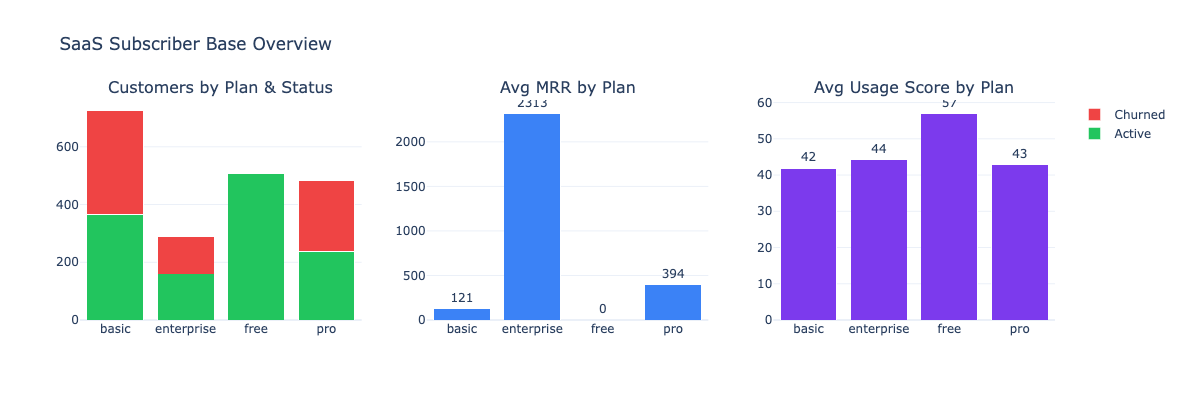


Total active MRR: $626,514
Annualized: $7,518,167


In [3]:
# ── Plan tier distribution with key metrics ──
plan = q("""
    SELECT plan_tier, status,
           COUNT(*) as customers,
           AVG(mrr) as avg_mrr,
           AVG(usage_score) as avg_usage,
           AVG(contract_months) as avg_contract
    FROM v_saas_customers_clean
    GROUP BY plan_tier, status ORDER BY plan_tier
""")

fig = make_subplots(rows=1, cols=3,
    subplot_titles=("Customers by Plan & Status", "Avg MRR by Plan", "Avg Usage Score by Plan"),
    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]])

plan_active = plan[plan.status == "active"]
plan_churned = plan[plan.status == "churned"]

fig.add_trace(go.Bar(name="Active", x=plan_active.plan_tier, y=plan_active.customers,
                     marker_color="#22c55e"), row=1, col=1)
fig.add_trace(go.Bar(name="Churned", x=plan_churned.plan_tier, y=plan_churned.customers,
                     marker_color="#ef4444"), row=1, col=1)

plan_mrr = plan.groupby("plan_tier").agg({"avg_mrr": "mean"}).reset_index()
fig.add_trace(go.Bar(x=plan_mrr.plan_tier, y=plan_mrr.avg_mrr, marker_color="#3b82f6",
                     text=plan_mrr.avg_mrr.round(0).astype(int), textposition="outside",
                     showlegend=False), row=1, col=2)

plan_usage = plan.groupby("plan_tier").agg({"avg_usage": "mean"}).reset_index()
fig.add_trace(go.Bar(x=plan_usage.plan_tier, y=plan_usage.avg_usage, marker_color="#7c3aed",
                     text=plan_usage.avg_usage.round(0).astype(int), textposition="outside",
                     showlegend=False), row=1, col=3)

fig.update_layout(height=400, width=1000, barmode="stack",
                  title_text="SaaS Subscriber Base Overview")
fig.show()

# Total MRR
total_mrr = q("SELECT SUM(mrr) as v FROM v_saas_customers_clean WHERE status='active'").v[0]
print(f"\nTotal active MRR: ${total_mrr:,.0f}")
print(f"Annualized: ${total_mrr * 12:,.0f}")


## 3. MRR Movements — The Revenue Engine

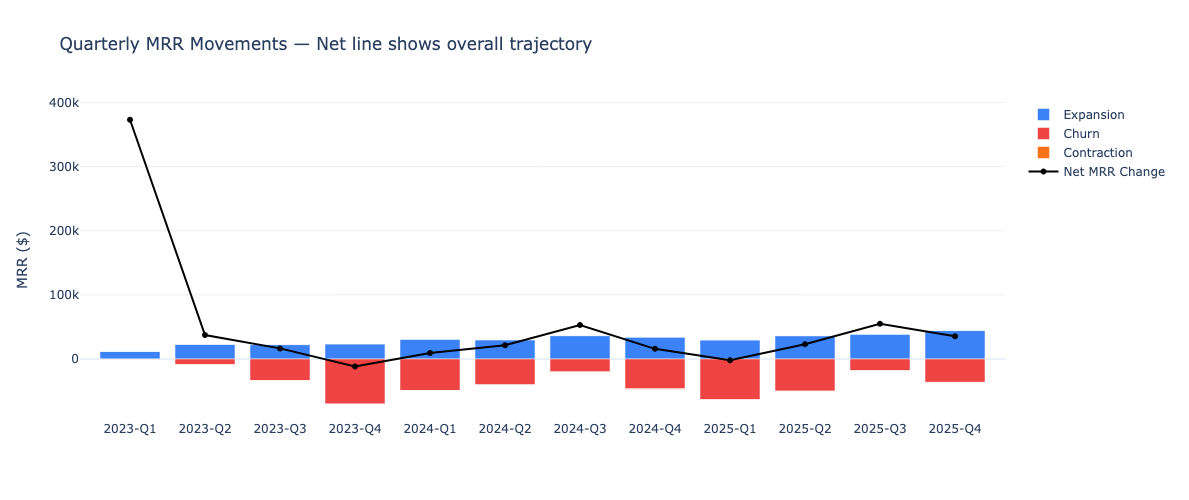


Quarterly net MRR change:
  2023-Q1: +$373,123
  2023-Q2: +$37,324
  2023-Q3: +$16,541
  2023-Q4: $-11,858
  2024-Q1: +$9,221
  2024-Q2: +$21,377
  2024-Q3: +$53,115
  2024-Q4: +$15,828
  2025-Q1: $-2,096
  2025-Q2: +$23,125
  2025-Q3: +$54,856
  2025-Q4: +$35,585


In [4]:
# ── MRR waterfall by quarter ──
mrr = q("""
    SELECT strftime('%Y', movement_date) || '-Q' ||
           ((CAST(strftime('%m', movement_date) AS INT) - 1) / 3 + 1) as quarter,
           movement_type,
           SUM(amount) as total,
           COUNT(*) as movements
    FROM mrr_movements
    GROUP BY quarter, movement_type ORDER BY quarter
""")

pivot = mrr.pivot_table(index="quarter", columns="movement_type", values="total", aggfunc="sum").fillna(0)
if "churn" in pivot.columns:
    pivot["churn"] = -abs(pivot["churn"])
if "contraction" in pivot.columns:
    pivot["contraction"] = -abs(pivot["contraction"])

fig = go.Figure()
colors = {"new_business": "#22c55e", "expansion": "#3b82f6",
          "churn": "#ef4444", "contraction": "#f97316"}
for col in ["new_business", "expansion", "churn", "contraction"]:
    if col in pivot.columns:
        fig.add_trace(go.Bar(x=pivot.index, y=pivot[col],
                             name=col.replace("_", " ").title(),
                             marker_color=colors.get(col, "#94a3b8")))

# Net MRR line
pivot["net"] = pivot.sum(axis=1)
fig.add_trace(go.Scatter(x=pivot.index, y=pivot.net, name="Net MRR Change",
                         mode="lines+markers", line=dict(color="black", width=2)))

fig.update_layout(barmode="relative", title="Quarterly MRR Movements — Net line shows overall trajectory",
                  height=500, width=950, yaxis_title="MRR ($)")
fig.show()

print("\nQuarterly net MRR change:")
for qtr, net in zip(pivot.index, pivot.net):
    direction = "+" if net > 0 else ""
    print(f"  {qtr}: {direction}${net:,.0f}")


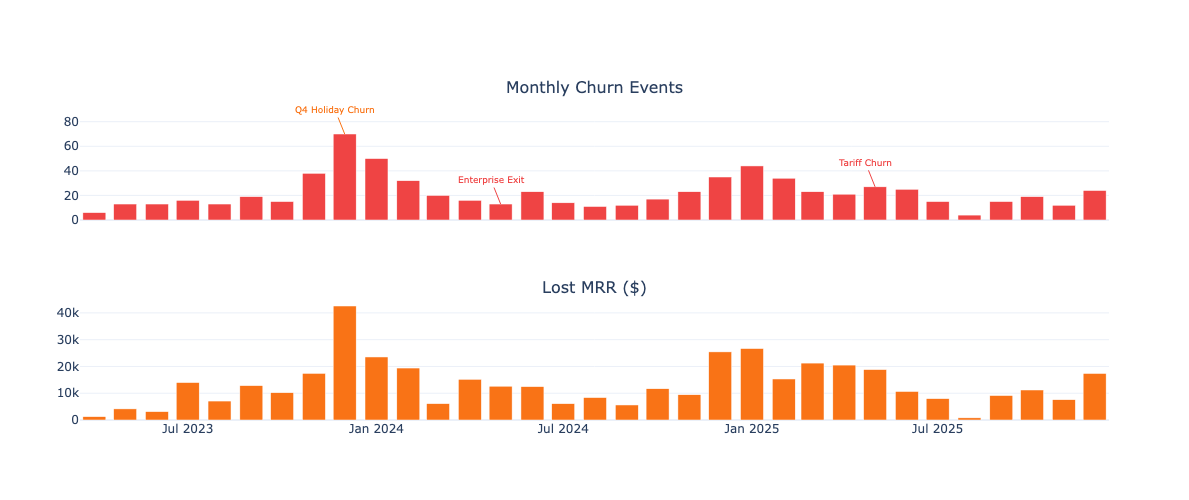

In [5]:
# ── Monthly churn events with storyline annotations ──
churn_monthly = q("""
    SELECT strftime('%Y-%m', movement_date) as month,
           COUNT(*) as churns,
           SUM(ABS(amount)) as lost_mrr
    FROM mrr_movements WHERE movement_type = 'churn'
    GROUP BY month ORDER BY month
""")

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Monthly Churn Events", "Lost MRR ($)"))
fig.add_trace(go.Bar(x=churn_monthly.month, y=churn_monthly.churns,
                     marker_color="#ef4444", name="Churns"), row=1, col=1)
fig.add_trace(go.Bar(x=churn_monthly.month, y=churn_monthly.lost_mrr,
                     marker_color="#f97316", name="Lost MRR"), row=2, col=1)

for month, label, color in [
    ("2023-12", "Q4 Holiday Churn", "#f97316"),
    ("2024-05", "Enterprise Exit", "#ef4444"),
    ("2025-05", "Tariff Churn", "#ef4444"),
]:
    if month in churn_monthly.month.values:
        y = churn_monthly[churn_monthly.month == month].churns.values[0]
        fig.add_annotation(x=month, y=y, text=label, showarrow=True, ay=-25,
                          font=dict(size=9, color=color), arrowcolor=color, row=1, col=1)

fig.update_layout(height=500, width=1000, showlegend=False)
fig.show()


## 4. Contract Cliff Analysis — When Do Customers Churn?

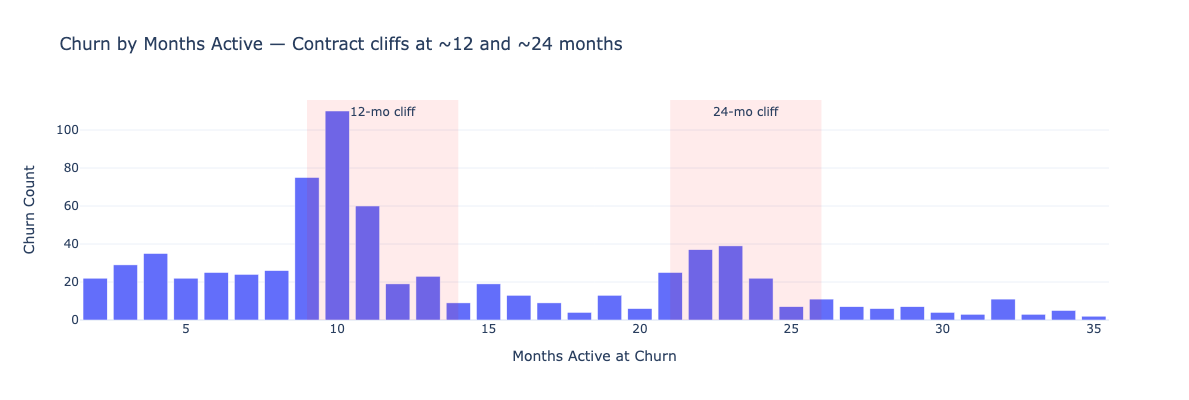


Churn clustering:
  12-month cliff (months 9-14): 296 churns (40% of all churn)
  24-month cliff (months 21-26): 141 churns (19% of all churn)
  Implication: Most churn happens at contract renewal. Retention efforts should start 60-90 days before renewal.


In [6]:
# ── Churn by months active ──
tenure = q("""
    SELECT CAST((julianday(m.movement_date) - julianday(s.signup_date)) / 30 AS INTEGER) as months_active,
           COUNT(*) as churns
    FROM mrr_movements m
    JOIN saas_customers s ON m.saas_customer_id = s.saas_customer_id
    WHERE m.movement_type = 'churn'
    GROUP BY months_active HAVING months_active BETWEEN 1 AND 36
    ORDER BY months_active
""")

fig = px.bar(tenure, x="months_active", y="churns",
             title="Churn by Months Active — Contract cliffs at ~12 and ~24 months",
             labels={"months_active": "Months Active at Churn", "churns": "Churn Count"})
fig.add_vrect(x0=9, x1=14, fillcolor="red", opacity=0.08, line_width=0,
              annotation_text="12-mo cliff", annotation_position="top")
fig.add_vrect(x0=21, x1=26, fillcolor="red", opacity=0.08, line_width=0,
              annotation_text="24-mo cliff", annotation_position="top")
fig.update_layout(height=400, width=900)
fig.show()

# Stats
peak_12 = tenure[(tenure.months_active >= 9) & (tenure.months_active <= 14)].churns.sum()
peak_24 = tenure[(tenure.months_active >= 21) & (tenure.months_active <= 26)].churns.sum()
total_churn = tenure.churns.sum()
print(f"\nChurn clustering:")
print(f"  12-month cliff (months 9-14): {peak_12} churns ({peak_12/total_churn*100:.0f}% of all churn)")
print(f"  24-month cliff (months 21-26): {peak_24} churns ({peak_24/total_churn*100:.0f}% of all churn)")
print(f"  Implication: Most churn happens at contract renewal. Retention efforts should start 60-90 days before renewal.")


## 5. Support Tickets — Leading Indicator of Churn?

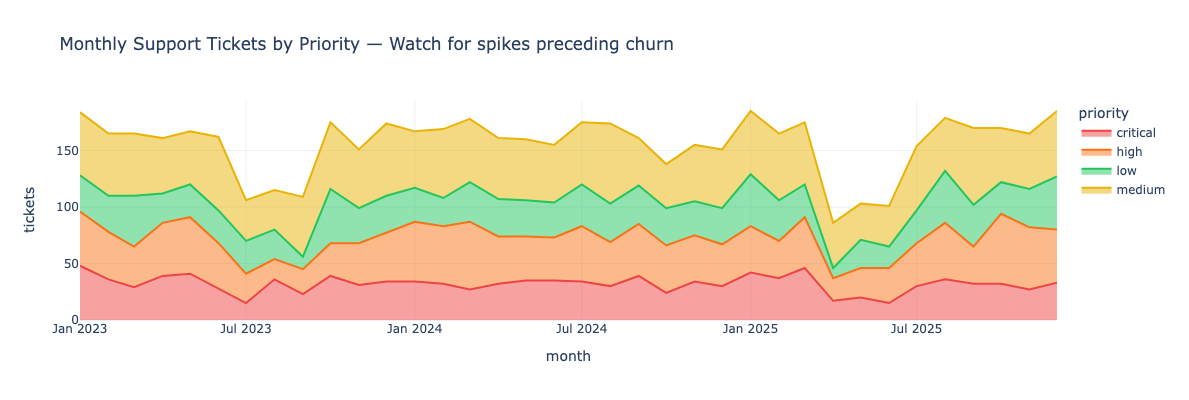

In [7]:
# ── Ticket volume over time by priority ──
tickets = q("""
    SELECT strftime('%Y-%m', created_date) as month,
           priority, COUNT(*) as tickets
    FROM v_support_tickets_clean
    GROUP BY month, priority ORDER BY month
""")

fig = px.area(tickets, x="month", y="tickets", color="priority",
              title="Monthly Support Tickets by Priority — Watch for spikes preceding churn",
              color_discrete_map={"critical":"#ef4444", "high":"#f97316",
                                   "medium":"#eab308", "low":"#22c55e"})
fig.update_layout(height=400, width=1000)
fig.show()


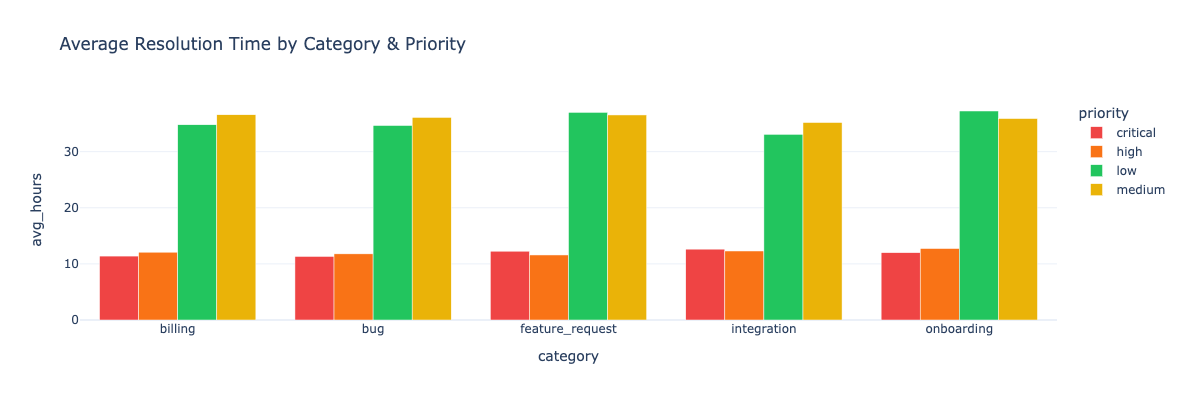


Unresolved tickets: 1,318 of 5,616 (23.5%)
  Note: ~10% have NULL resolved_date from messiness injection


In [8]:
# ── Resolution time by category ──
res = q("""
    SELECT category, priority,
           COUNT(*) as tickets,
           AVG(resolution_hours) as avg_hours,
           COUNT(CASE WHEN resolved_date IS NULL THEN 1 END) as unresolved
    FROM support_tickets
    GROUP BY category, priority ORDER BY category
""")

fig = px.bar(res, x="category", y="avg_hours", color="priority",
             barmode="group", title="Average Resolution Time by Category & Priority",
             color_discrete_map={"critical":"#ef4444", "high":"#f97316",
                                  "medium":"#eab308", "low":"#22c55e"})
fig.update_layout(height=400, width=900)
fig.show()

# Unresolved tickets
total_tickets = q("SELECT COUNT(*) as n FROM support_tickets").n[0]
unresolved = q("SELECT COUNT(*) as n FROM support_tickets WHERE resolved_date IS NULL").n[0]
print(f"\nUnresolved tickets: {unresolved:,} of {total_tickets:,} ({unresolved/total_tickets*100:.1f}%)")
print("  Note: ~10% have NULL resolved_date from messiness injection")


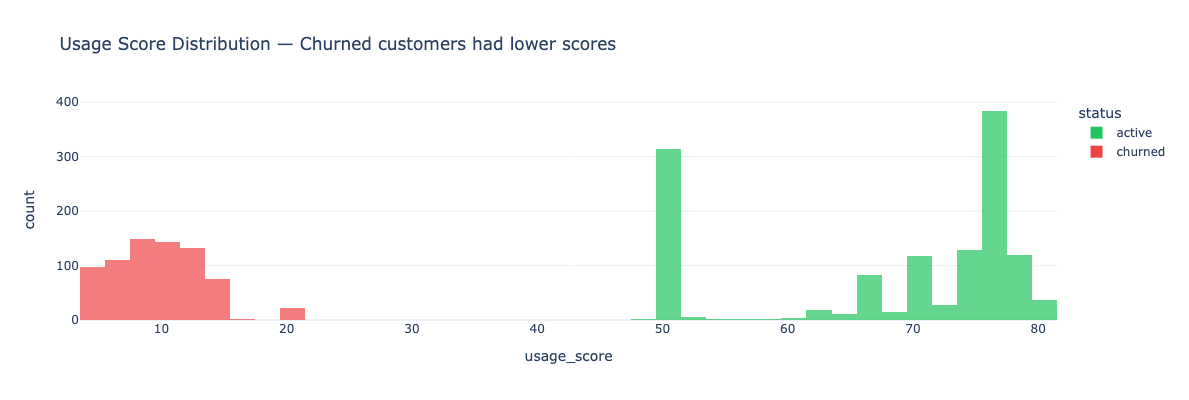


Avg usage score:
  active: 68.1
  churned: 9.7


In [9]:
# ── Usage score distribution: churned vs active ──
usage = q("""
    SELECT usage_score, status FROM v_saas_customers_clean
""")

fig = px.histogram(usage, x="usage_score", color="status", barmode="overlay",
                   nbins=40, title="Usage Score Distribution — Churned customers had lower scores",
                   color_discrete_map={"active":"#22c55e", "churned":"#ef4444"},
                   opacity=0.7)
fig.update_layout(height=400, width=800)
fig.show()

print("\nAvg usage score:")
for status in ["active", "churned"]:
    avg = usage[usage.status == status].usage_score.mean()
    print(f"  {status}: {avg:.1f}")


## 6. Summary & Key Findings

### Business Health
- **Active MRR:** ~$500K/month from 1,268 active subscribers
- **Churn rate:** 36.6% lifetime (732 of 2,000), but most at contract renewal points
- **Net MRR:** Generally positive — new business + expansion outpacing churn most quarters

### Storylines Discovered
1. **Contract Cliffs** — Churn clusters at 12 and 24 months. These are renewal decision points.
2. **Q4 2023 Elevated Churn** — Biggest churn quarter. Holiday-related budget cuts?
3. **Q2 2024 Enterprise Churn** — Fewer churns but high MRR impact (large accounts leaving)
4. **Q2 2025 Tariff Churn** — Elevated churn coincides with e-commerce volatility
5. **Usage Score = Leading Indicator** — Churned customers had measurably lower usage scores

### Data Quality Notes
- ~10% of support tickets have NULL resolved_date and resolution_hours (messiness injection)
- All SaaS customers tied to valid customer_ids (0 excluded in clean view)

### Recommendations
- Implement health score monitoring 90 days before renewal dates
- Investigate enterprise churn cases — small volume but outsized MRR impact
- Track support ticket volume as early warning signal

In [10]:
conn.close()
print('Notebook complete.')

Notebook complete.
